In [2]:
from rich.jupyter import display

# SQL Query
SQL = """
     SELECT
       cs.canonical_smiles AS smiles,
       -- r.compound_key AS compound_key,
       a.description AS description,
       a.chembl_id AS assay_chembl_id,
       a.assay_type AS assay_type,
       a.bao_format AS bao_format,
       -- act.bao_endpoint AS bao_endpoint, -- =IC50
       act.qudt_units as qudt_units,
       act.activity_id AS activity_id,
       td.pref_name AS target_name,
       -- td.target_type AS target_type,
       -- act.standard_type AS standard_type,
       act.standard_value AS standard_value,
       act.standard_units AS standard_units,
       act.standard_relation AS standard_relation,
       COALESCE(act.pchembl_value, ROUND(9 - LOG(10, act.standard_value), 2)) AS pchembl_value, --pIC50
       m.chembl_id AS molecule_chembl_id,
       cp.heavy_atoms AS heavy_atoms,
       (1.37 * COALESCE(act.pchembl_value, ROUND(9 - LOG(10, act.standard_value), 2))) / cp.heavy_atoms AS ligand_efficiency
     -- act.assay_id AS assay_id
     -- td.organism AS target_organism,
     -- td.chembl_id AS chembl_id
     FROM compound_structures cs
            RIGHT JOIN molecule_dictionary m ON cs.molregno = m.molregno
            JOIN compound_records r ON m.molregno = r.molregno
            JOIN compound_properties cp ON m.molregno = cp.molregno
            JOIN docs d ON r.doc_id = d.doc_id
            JOIN activities act ON r.record_id = act.record_id
            JOIN assays a ON act.assay_id = a.assay_id
            JOIN target_dictionary td ON a.tid = td.tid
     WHERE act.standard_type = 'IC50'
       AND act.standard_relation = '='
       AND act.standard_units = 'nM'
       --AND ass.confidence_score >= 7
       AND act.standard_value BETWEEN 0.001 and 100000
       AND (act.pchembl_value IS NOT NULL OR act.standard_value > 0)
       AND td.organism = 'Homo sapiens'
       AND td.chembl_id = 'CHEMBL203'
       AND m.chembl_id IN
           (SELECT DISTINCT m1.chembl_id
            FROM molecule_dictionary m1
                   JOIN molecule_hierarchy mh ON mh.molregno = m1.molregno
                   JOIN molecule_dictionary m2 ON mh.parent_molregno = m2.molregno)
       LIMIT 50000;
     """

In [3]:
# Imports
# import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
import rdkit
import gdown

from polars import col
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw
from IPython.display import Image

In [4]:
# Basic data checks
PARQUET_PATH = "data/eda_ready.parquet"
df = pd.read_parquet(PARQUET_PATH)
assert isinstance(df, pd.DataFrame) # Ensure df is a pandas DataFrame

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18711 entries, 0 to 18710
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   smiles              18705 non-null  object 
 1   description         18711 non-null  object 
 2   assay_chembl_id     18711 non-null  object 
 3   assay_type          18711 non-null  object 
 4   bao_format          18711 non-null  object 
 5   qudt_units          18711 non-null  object 
 6   activity_id         18711 non-null  int64  
 7   target_name         18711 non-null  object 
 8   standard_value      18711 non-null  float64
 9   standard_units      18711 non-null  object 
 10  standard_relation   18711 non-null  object 
 11  pchembl_value       18711 non-null  float64
 12  molecule_chembl_id  18711 non-null  object 
 13  heavy_atoms         18501 non-null  float64
 14  ligand_efficiency   18501 non-null  float64
dtypes: float64(4), int64(1), object(10)
memory usage: 2.1

,activity_id,standard_value,pchembl_value,heavy_atoms,ligand_efficiency
count,1.871100e+04,18711.000000,18711.000000,18501.000000,18501.000000
mean,1.742620e+07,2841.720315,7.069817,34.105778,0.298107
std,9.976647e+06,10295.327132,1.334215,7.943782,0.084883
min,3.226000e+04,0.002000,4.000000,8.000000,0.088463
25%,8.058280e+06,8.314000,6.110000,29.000000,0.243638
50%,1.857755e+07,70.400000,7.150000,34.000000,0.285417
75%,2.658765e+07,779.500000,8.080000,39.000000,0.336078
max,2.902572e+07,100000.000000,11.700000,72.000000,1.245455


Original DataFrame shape: (18711, 15)
Features to drop due to high correlation (> 0.8): 0
DataFrame shape after dropping correlated features: (18711, 15)
Removed 0 features


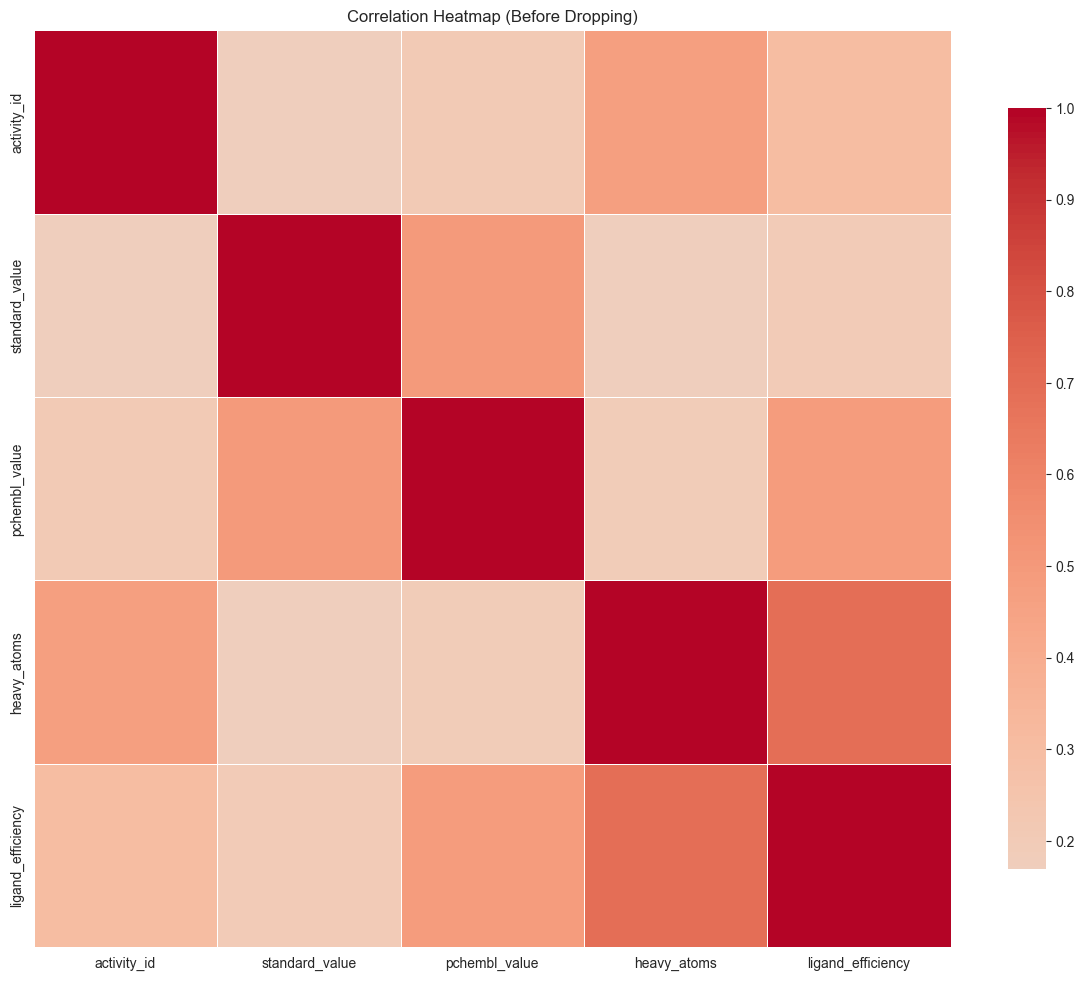

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18711 entries, 0 to 18710
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   smiles              18705 non-null  object 
 1   description         18711 non-null  object 
 2   assay_chembl_id     18711 non-null  object 
 3   assay_type          18711 non-null  object 
 4   bao_format          18711 non-null  object 
 5   qudt_units          18711 non-null  object 
 6   activity_id         18711 non-null  int64  
 7   target_name         18711 non-null  object 
 8   standard_value      18711 non-null  float64
 9   standard_units      18711 non-null  object 
 10  standard_relation   18711 non-null  object 
 11  pchembl_value       18711 non-null  float64
 12  molecule_chembl_id  18711 non-null  object 
 13  heavy_atoms         18501 non-null  float64
 14  ligand_efficiency   18501 non-null  float64
dtypes: float64(4), int64(1), object(10)
memory usage: 2.1

,activity_id,standard_value,pchembl_value,heavy_atoms,ligand_efficiency
count,1.871100e+04,18711.000000,18711.000000,18501.000000,18501.000000
mean,1.742620e+07,2841.720315,7.069817,34.105778,0.298107
std,9.976647e+06,10295.327132,1.334215,7.943782,0.084883
min,3.226000e+04,0.002000,4.000000,8.000000,0.088463
25%,8.058280e+06,8.314000,6.110000,29.000000,0.243638
50%,1.857755e+07,70.400000,7.150000,34.000000,0.285417
75%,2.658765e+07,779.500000,8.080000,39.000000,0.336078
max,2.902572e+07,100000.000000,11.700000,72.000000,1.245455


In [5]:
# Correlation analysis, drop strongly correlated features (threshold 0.8)
print("Original DataFrame shape:", df.shape)

# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Calculate correlation matrix
correlation_matrix = numeric_df.corr().abs()

# Create a mask for upper triangle
upper_triangle = np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
upper_corr = correlation_matrix.where(upper_triangle)

# Find features with correlation > 0.8
to_drop = [column for column in upper_corr.columns if any(upper_corr[column] > 0.8)]

print(f"Features to drop due to high correlation (> 0.8): {len(to_drop)}")
if to_drop:
    print("Dropping:", to_drop)

# Drop highly correlated features
df_cleaned = df.drop(columns=to_drop)

print(f"DataFrame shape after dropping correlated features: {df_cleaned.shape}")
print(f"Removed {len(to_drop)} features")

# Visualize correlation heatmap before dropping
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap (Before Dropping)')
plt.tight_layout()
plt.show()

# Update df with cleaned version
df = df_cleaned
df.head()
df.info()
df.describe()


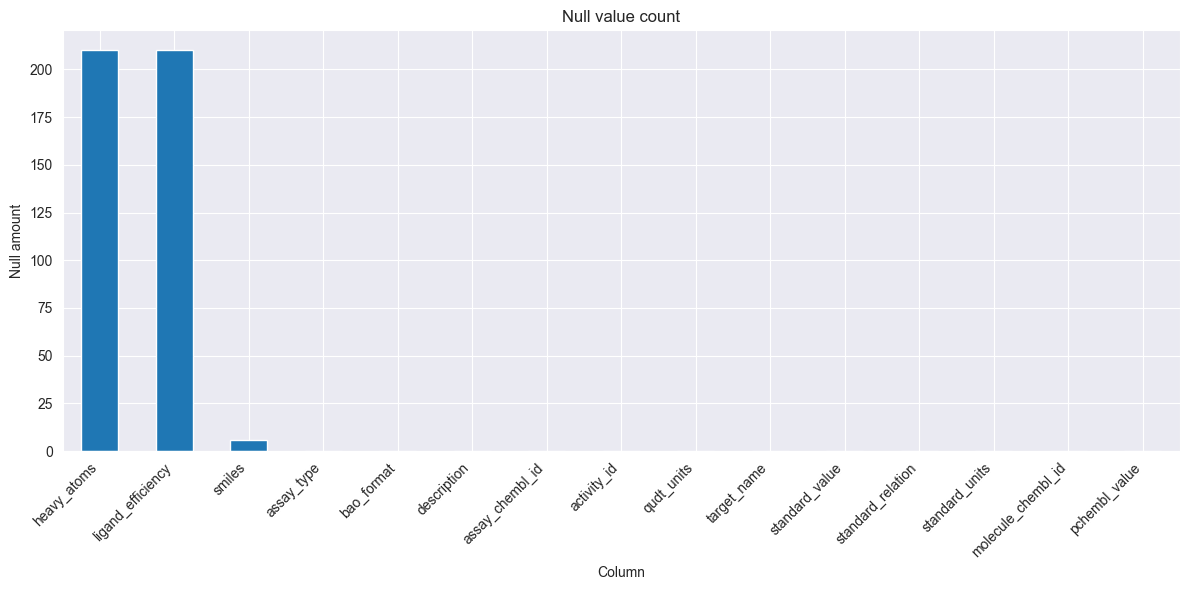

In [6]:
# Null values check
null_columns = {}
for column in df.columns:
    null_count = df[column].isnull().sum()
    null_columns[column] = null_count

# Visualize null values
plt.figure(figsize=(12, 6))
null_counts = pd.Series(null_columns)


if len(null_counts) > 0:
    null_counts.sort_values(ascending=False).plot(kind='bar')
    plt.title('Null value count')
    plt.xlabel('Column')
    plt.ylabel('Null amount')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No null values found in the DataFrame.")


In [7]:
# Do przemyślenia: wyliczenie ECFP (Extended Connectivity Fingerprints) dla każdego związku chemicznego, co pozwoli na reprezentację struktury chemicznej w formie wektorowej, gotowej do użycia w modelach ML.

In [8]:
df_dist = df[["smiles", "molecule_chembl_id", "standard_value", "standard_units", "standard_relation", "pchembl_value"]]
assert isinstance(df_dist, pd.DataFrame) # Ensure df is a pandas DataFrame
df_dist.head()

,smiles,molecule_chembl_id,standard_value,standard_units,standard_relation,pchembl_value
0,O=C(/C=C/c1ccc(O)c(O)c1)OCCc1ccccc1,CHEMBL319244,1005.0,nM,=,6.00
1,C=CC(=O)N1CC(Nc2nc(-c3cnn(C)c3)c3c(c2F)CNC3=O)...,CHEMBL5853228,6694.0,nM,=,5.17
2,COc1ccccc1-c1cc2c(NC(C)c3ccccc3)ncnc2s1,CHEMBL3416591,19.0,nM,=,7.72
3,Cc1nc(C)c(/C=C2\CN(C(C)C)C/C(=C\c3nc(C)c(C)nc3...,CHEMBL4104427,2500.0,nM,=,5.60
4,Cc1nc(F)ccc1[C@H](Nc1cc(Cl)c2ncc(C#N)c(NCC(C)(...,CHEMBL6027273,3.0,nM,=,8.52


In [9]:
# Double-check unique values in categorical columns
print(df_dist["standard_units"].value_counts())
print(df_dist["standard_relation"].value_counts())

standard_units
nM    18711
Name: count, dtype: int64
standard_relation
=    18711
Name: count, dtype: int64


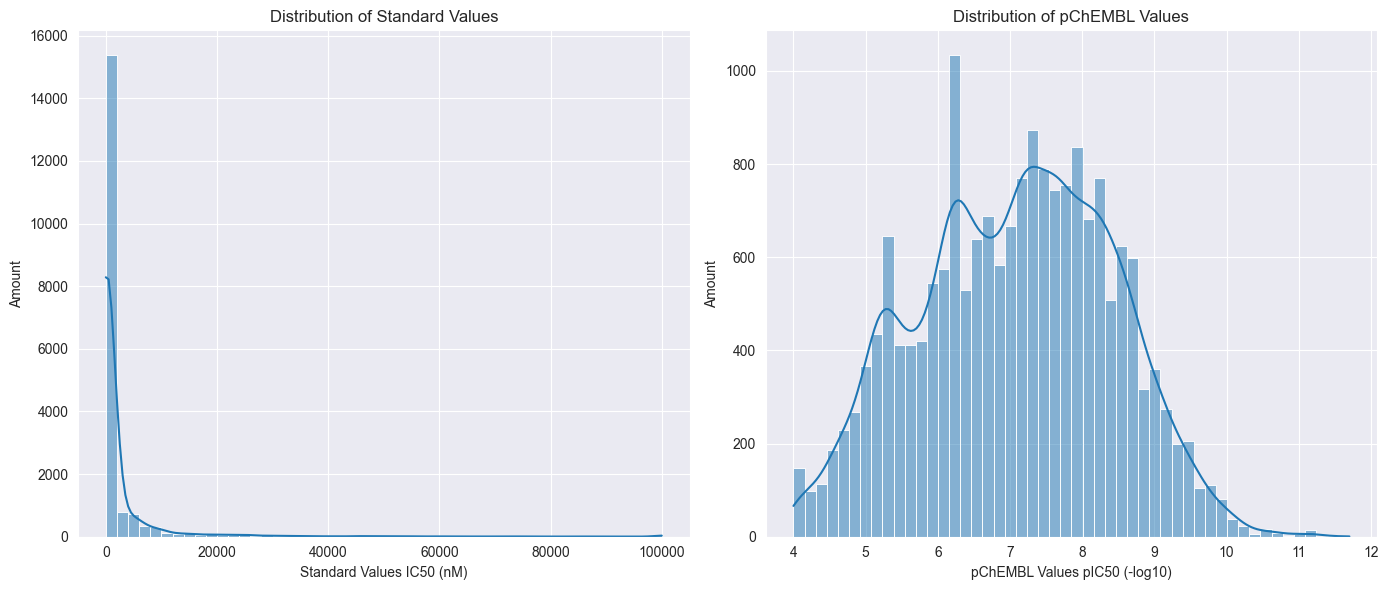

In [10]:
# standard_value and pchembl_value distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.histplot(df_dist["standard_value"], bins=50, ax=axes[0], kde=True)
axes[0].set_title("Distribution of Standard Values")
axes[0].set_xlabel("Standard Values IC50 (nM)")
axes[0].set_ylabel("Amount")

sns.histplot(df_dist["pchembl_value"], bins=50, ax=axes[1], kde=True)
axes[1].set_title("Distribution of pChEMBL Values")
axes[1].set_xlabel("pChEMBL Values pIC50 (-log10)")
axes[1].set_ylabel("Amount")

plt.tight_layout()
plt.show()

In [11]:
df_eda = df[["smiles", "molecule_chembl_id", "standard_value", "standard_units",
             "standard_relation", "pchembl_value", "description"]].copy()
df_eda.dropna(subset=["smiles", "standard_value", "pchembl_value"], inplace=True)
df_eda = df_eda.rename(columns={'standard_value': 'IC50', 'pchembl_value': 'pIC50'})
assert isinstance(df_eda, pd.DataFrame) # Ensure df is a pandas DataFrame
print(df.shape)
print(df_eda.shape)

(18711, 15)
(18705, 7)


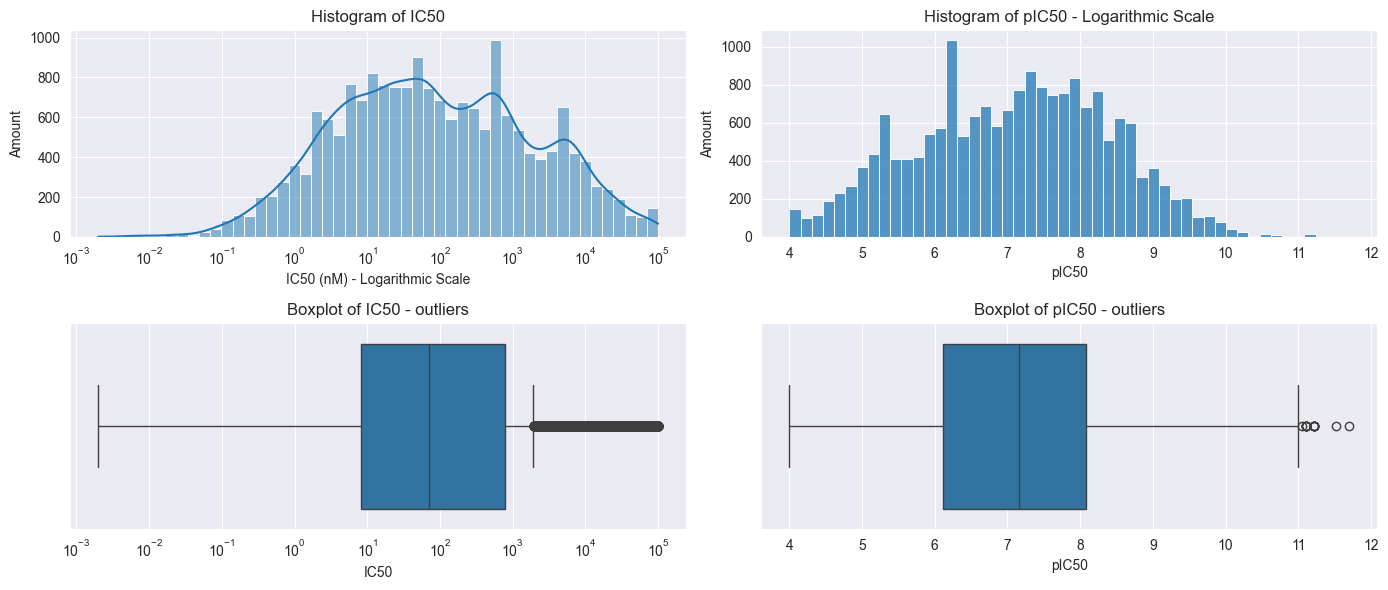

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
sns.histplot(df_eda["IC50"], bins=50, ax=axes[0, 0], kde=True, log_scale=True)
axes[0, 0].set_title("Histogram of IC50")
axes[0, 0].set_xlabel("IC50 (nM) - Logarithmic Scale")
axes[0, 0].set_ylabel("Amount")

sns.histplot(df_eda["pIC50"], bins=50, ax=axes[0, 1], kde=False)
axes[0, 1].set_title("Histogram of pIC50 - Logarithmic Scale")
axes[0, 1].set_xlabel("pIC50")
axes[0, 1].set_ylabel("Amount")

sns.boxplot(x=df_eda["IC50"], ax=axes[1, 0])
axes[1, 0].set_xscale('log')
axes[1, 0].set_title("Boxplot of IC50 - outliers")

sns.boxplot(x=df_eda["pIC50"], ax=axes[1, 1])
axes[1, 1].set_title("Boxplot of pIC50 - outliers")

plt.tight_layout()
plt.show()

In [13]:
# Remove outliers
q25 = df_eda["pIC50"].quantile(0.25)
q75 = df_eda["pIC50"].quantile(0.75)
iqr = q75 - q25
upper_bound = q75 + 1.5 * iqr

print(f"Threshold for outliers {upper_bound:.2f}")

df_eda_no_outliers = df_eda[df_eda["pIC50"] <= upper_bound]
print(df_eda.shape)
print(df_eda_no_outliers.shape)
print(f"Removed {df_eda.shape[0] - df_eda_no_outliers.shape[0]} outliers")

Threshold for outliers 11.04
(18705, 7)
(18688, 7)
Removed 17 outliers


In [14]:
print(f"Max pIC50: {df_eda_no_outliers['pIC50'].max():.2f}")
print(f"Min pIC50: {df_eda_no_outliers['pIC50'].min():.2f}")
print(f"Mean pIC50: {df_eda_no_outliers['pIC50'].mean():.2f}")
print(f"Median pIC50: {df_eda_no_outliers['pIC50'].median():.2f}")

Max pIC50: 11.00
Min pIC50: 4.00
Mean pIC50: 7.07
Median pIC50: 7.15


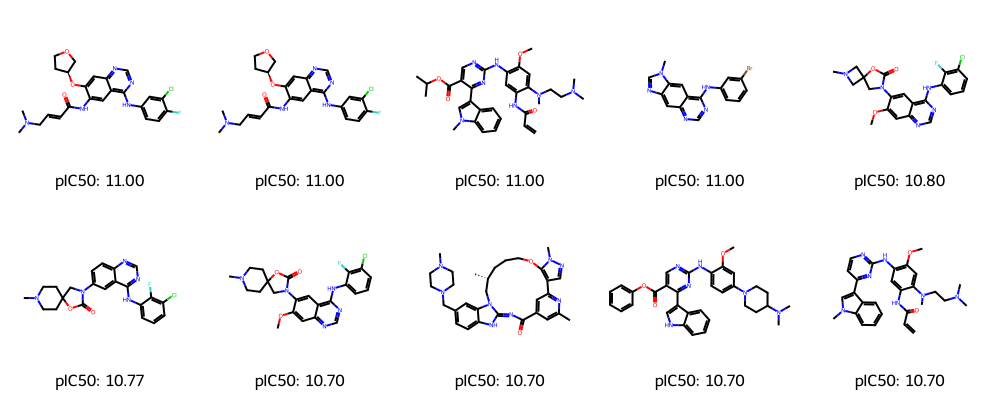

In [15]:
top_10 = df_eda_no_outliers.sort_values(by="pIC50", ascending=False).head(10)
mols = [Chem.MolFromSmiles(smiles) for smiles in top_10["smiles"]]
img = Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(200, 200), legends=[f"pIC50: {pIC50:.2f}" for pIC50 in top_10["pIC50"]])
img

Unique scaffolds: 3842
Average pIC50 for a single scaffold: 6.84


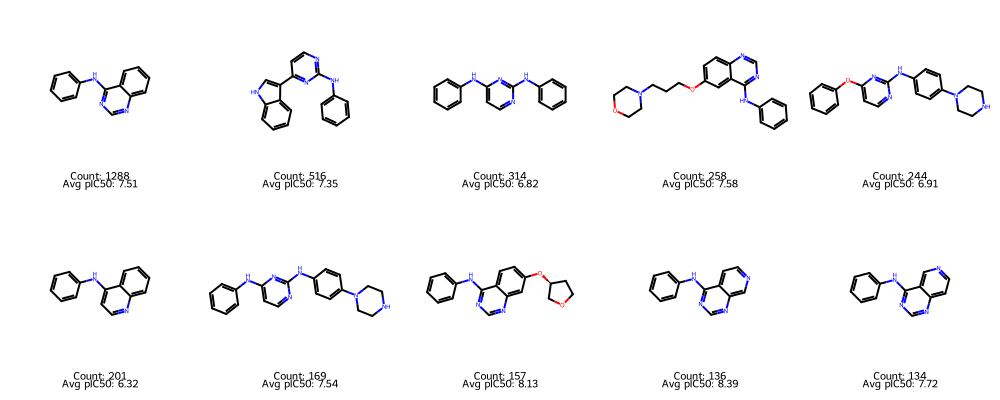

In [16]:
# Bamis-Murcko scaffold analysis
from rdkit.Chem.Scaffolds import MurckoScaffold
def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaffold)
    return None


scaffolds = df_eda[["smiles", "pIC50"]].copy()
scaffolds["scaffold"] = scaffolds["smiles"].apply(get_scaffold)

# Check how many times the scaffold appears and its average pIC50
scaffold_stats = scaffolds.groupby("scaffold").agg(
    count=("pIC50", "count"),
    avg_pIC50=("pIC50", "mean")
).reset_index()

print(f"Unique scaffolds: {scaffold_stats.shape[0]}")
print(f"Average pIC50 for a single scaffold: {scaffold_stats['avg_pIC50'].mean():.2f}")

# Visualize top 10 scaffolds by count
top_scaffolds = scaffold_stats.sort_values(by="count", ascending=False).head(10)
mols = [Chem.MolFromSmiles(scaffold) for scaffold in top_scaffolds["scaffold"]]
legends = [f"Count: {count}\nAvg pIC50: {avg_pIC50:.2f}" for count, avg_pIC50 in zip(top_scaffolds["count"], top_scaffolds["avg_pIC50"])]
img = Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(200, 200), legends=legends)
img

# Lipinski's Rule of Five analysis
Lipinski's Rule of Five is a set of guidelines for evaluating the drug-likeness of a compound, that is, its potential to be an orally active drug in humans and being successfully absorbed by the digestive system. The rules are:
1. Compound mass <= 500 Da. Otherwise, the compound may have poor absorption or permeation.
2. LogP <= 5. A higher LogP indicates that the compound is more lipophilic, which can lead to poor solubility and absorption.
3. Hydrogen bond donors <= 5. Sum of OH and NH groups. Too many hydrogen bond donors can reduce membrane permeability.
4. Hydrogen bond acceptors <= 10. Sum of N and O atoms. Too many hydrogen bond acceptors can also reduce membrane permeability.

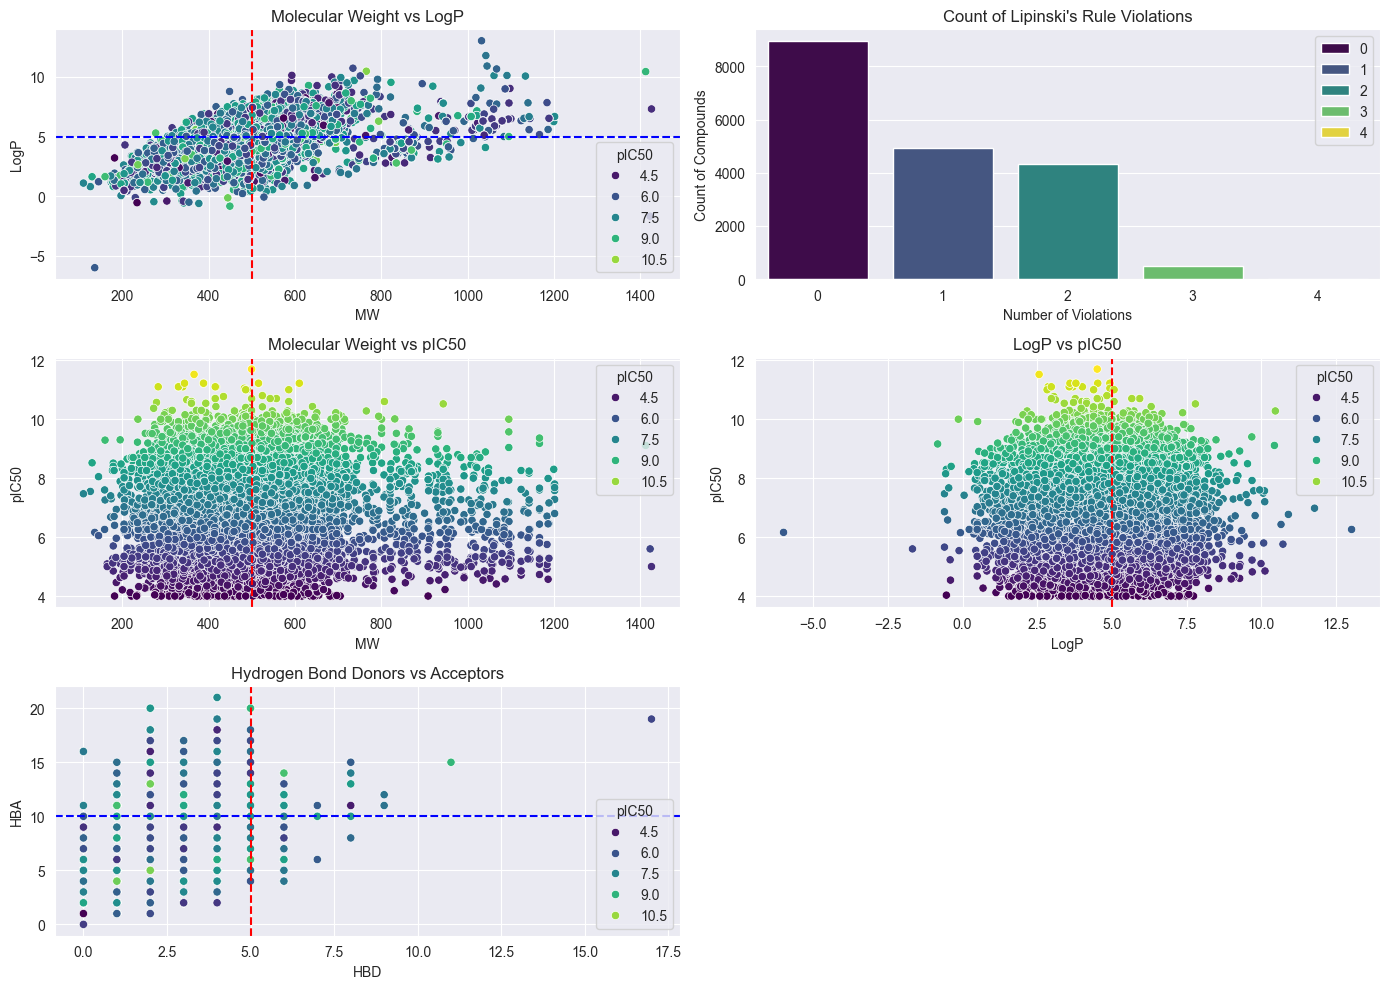

In [17]:
from rdkit.Chem import Descriptors

def calculate_lipinski(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        mw = Descriptors.MolWt(mol)  # Molecular weight
        logp = Descriptors.MolLogP(mol)  # LogP
        hbd = Descriptors.NumHDonors(mol)  # Hydrogen bond donors
        hba = Descriptors.NumHAcceptors(mol)  # Hydrogen bond acceptors
        return {"MW": mw,
            "LogP": logp,
            "HBD": hbd,
            "HBA": hba
        }
    return {"MW": None, "LogP": None, "HBD": None, "HBA": None}

lipinski_results = df_eda["smiles"].apply(calculate_lipinski)
lipinski_df = pd.DataFrame(lipinski_results.tolist())
# Combine with original DataFrame
df_lipinski = pd.concat([df_eda, lipinski_df], axis=1)
# Check how many compounds violate Lipinski's rules
violations = {
    "MW": (df_lipinski["MW"] > 500).sum(),
    "LogP": (df_lipinski["LogP"] > 5).sum(),
    "HBD": (df_lipinski["HBD"] > 5).sum(),
    "HBA": (df_lipinski["HBA"] > 10).sum()
}
viol_mask = pd.DataFrame({
    "MW": df_lipinski["MW"] > 500,
    "LogP": df_lipinski["LogP"] > 5,
    "HBD": df_lipinski["HBD"] > 5,
    "HBA": df_lipinski["HBA"] > 10
}).fillna(False)

df_lipinski["lipinski_violations"] = viol_mask.sum(axis=1).astype(int)
violation_counts = df_lipinski["lipinski_violations"].value_counts().sort_index()
counts_list = [int(violation_counts.get(i, 0)) for i in range(5)]

# Visualization
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
# MW vs LogP
sns.scatterplot(data=df_lipinski, x="MW", y="LogP", hue="pIC50", palette="viridis", ax=axes[0, 0])
axes[0, 0].axvline(500, color='red', linestyle='--', label='MW = 500')
axes[0, 0].axhline(5, color='blue', linestyle='--', label='LogP = 5')
axes[0, 0].set_title("Molecular Weight vs LogP")

# Violation counts
sns.barplot(x=list(range(5)), y=counts_list, hue=list(range(5)), palette="viridis", ax=axes[0, 1])
axes[0, 1].set_title("Count of Lipinski's Rule Violations")
axes[0, 1].set_xlabel("Number of Violations")
axes[0, 1].set_ylabel("Count of Compounds")


# MW vs pIC50
sns.scatterplot(data=df_lipinski, x="MW", y="pIC50", hue="pIC50", palette="viridis", ax=axes[1, 0])
axes[1, 0].axvline(500, color='red', linestyle='--', label='MW = 500')
axes[1, 0].set_title("Molecular Weight vs pIC50")

# LogP vs pIC50
sns.scatterplot(data=df_lipinski, x="LogP", y="pIC50", hue="pIC50", palette="viridis", ax=axes[1, 1])
axes[1, 1].axvline(5, color='red', linestyle='--', label='LogP = 5')
axes[1, 1].set_title("LogP vs pIC50")

# HBD vs HBA
sns.scatterplot(data=df_lipinski, x="HBD", y="HBA", hue="pIC50", palette="viridis", ax=axes[2, 0])
axes[2, 0].axvline(5, color='red', linestyle='--', label='HBD = 5')
axes[2, 0].axhline(10, color='blue', linestyle='--', label='HBA = 10')
axes[2, 0].set_title("Hydrogen Bond Donors vs Acceptors")

# Hide the empty subplot
axes[2, 1].axis('off')

plt.tight_layout()
plt.show()



## Feature Engineering & Selection

### Current Features (Lipinski's Rule of Five)

Currently, the notebook uses 4 molecular descriptors:

1. **MW (Molecular Weight)** - Total molecular mass
2. **LogP (Lipophilicity)** - Partition coefficient (lipophilicity)
3. **HBD (Hydrogen Bond Donors)** - Number of H-bond donors
4. **HBA (Hydrogen Bond Acceptors)** - Number of H-bond acceptors

**Target variable:** pIC50 (negative logarithm of IC50)

---

### Features to be considered

#### 1. **Structural Complexity**
- **TPSA (Topological Polar Surface Area)** - Important for drug absorption
- **Number of Rotatable Bonds** - Measure of molecular flexibility
- **Number of Rings** (aromatic, aliphatic, heterocyclic)
- **Fraction of sp³ carbons** - Indicator of 3D complexity
- **Bertz Complexity Index** - Overall molecular complexity

#### 2. **Electronic Properties**
- **Number of Valence Electrons**
- **Partial Charges** (max/min)
- **Dipole Moment** (if 3D structure available)

#### 3. **Topological Indices**
- **Kappa Indices (κ1, κ2, κ3)** - Shape descriptors
- **Chi Indices (χ0-χ4)** - Molecular connectivity
- **Hall-Kier Alpha** - Covalent hydrogen bond ability

#### 4. **Functional Groups**
- **Number of Amide Bonds**
- **Number of Aromatic Heterocycles**
- **Number of Bridgehead/Spiro Atoms**
- **Specific functional group counts** (OH, NH2, COOH, etc.)

#### 5. **Pharmacophore Features**
- **LabuteASA (Accessible Surface Area)**
- **MolMR (Molar Refractivity)**
- **Number of Heavy Atoms**
- **Exact Molecular Weight**

#### 6. **Fingerprints (Advanced)**
- **Morgan Fingerprints** (circular fingerprints, ECFP)
- **MACCS Keys** (166-bit structural keys)
- **Atom Pair Fingerprints**
- **Topological Torsion Fingerprints**

---


In [18]:
# Build baseline MLP
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

from rdkit import DataStructs
from rdkit.Chem import AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold


@dataclass
class MLPBaselineConfig:
    smiles_col: str = "smiles"
    ic50_col: str = "IC50"  # expected numeric, typically nM

    radius: int = 2
    n_bits: int = 2048

    hidden1: int = 512
    hidden2: int = 128
    dropout: float = 0.2

    batch_size: int = 256
    epochs: int = 20
    lr: float = 1e-3
    weight_decay: float = 0.0

    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


def _seed_everything(seed: int) -> None:
    random = __import__("random")
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def smiles_to_morgan_fp(smiles: str, radius: int, n_bits: int) -> Optional[np.ndarray]:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr


def build_ml_dataset(df_in: pd.DataFrame, cfg: MLPBaselineConfig) -> Tuple[np.ndarray, np.ndarray]:
    """Returns X (float32, shape [N, 2048]) and y (float32, shape [N, 1]).

    Drops rows with:
      - missing SMILES / IC50
      - invalid SMILES (RDKit cannot parse)
      - non-positive IC50 (cannot be used reliably)
    """
    if cfg.smiles_col not in df_in.columns:
        raise KeyError(f"Missing column: {cfg.smiles_col}")
    if cfg.ic50_col not in df_in.columns:
        raise KeyError(f"Missing column: {cfg.ic50_col}")

    df_work = df_in[[cfg.smiles_col, cfg.ic50_col]].copy()
    df_work = df_work.dropna(subset=[cfg.smiles_col, cfg.ic50_col])

    # convert IC50 to numeric (coerce errors to NaN, then drop)
    df_work[cfg.ic50_col] = pd.to_numeric(df_work[cfg.ic50_col], errors="coerce")
    df_work = df_work.dropna(subset=[cfg.ic50_col])

    # remove invalid / non-positive IC50
    df_work = df_work[df_work[cfg.ic50_col] > 0].copy()

    fps: List[np.ndarray] = []
    ys: List[float] = []

    for smi, ic50 in zip(df_work[cfg.smiles_col].astype(str), df_work[cfg.ic50_col].astype(float)):
        fp = smiles_to_morgan_fp(smi, cfg.radius, cfg.n_bits)
        if fp is None:
            continue
        fps.append(fp)
        ys.append(float(ic50))

    if not fps:
        raise ValueError("No valid SMILES/IC50 rows after featurization")

    X = np.stack(fps).astype(np.float32)
    y = np.asarray(ys, dtype=np.float32).reshape(-1, 1)
    return X, y


class NumpyDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self) -> int:
        return self.X.shape[0]

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]


def build_mlp(cfg: MLPBaselineConfig) -> nn.Module:
    model = nn.Sequential(
        nn.Linear(cfg.n_bits, cfg.hidden1),
        nn.ReLU(),
        nn.Dropout(cfg.dropout),
        nn.Linear(cfg.hidden1, cfg.hidden2),
        nn.ReLU(),
        nn.Dropout(cfg.dropout),
        nn.Linear(cfg.hidden2, 1),
    )

    def init_weights(m: nn.Module) -> None:
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            nn.init.zeros_(m.bias)

    model.apply(init_weights)
    return model


@torch.no_grad()
def evaluate_regression(model: nn.Module, loader: DataLoader, device: str) -> Dict[str, float]:
    model.eval()

    preds: List[np.ndarray] = []
    trues: List[np.ndarray] = []

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        pred = model(xb)
        preds.append(pred.detach().cpu().numpy())
        trues.append(yb.detach().cpu().numpy())

    p = np.vstack(preds).reshape(-1)
    y = np.vstack(trues).reshape(-1)

    mse = float(np.mean((p - y) ** 2))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(p - y)))

    # R2 (manual, to avoid extra deps)
    denom = float(np.sum((y - np.mean(y)) ** 2))
    r2 = float(1.0 - (np.sum((p - y) ** 2) / denom)) if denom > 0 else float("nan")

    return {"mse": mse, "rmse": rmse, "mae": mae, "r2": r2}


def random_split_indices(n: int, seed: int = 42) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    idx = np.arange(n)
    rng.shuffle(idx)

    n_train = int(0.8 * n)
    n_val = int(0.1 * n)

    train_idx = idx[:n_train]
    val_idx = idx[n_train : n_train + n_val]
    test_idx = idx[n_train + n_val :]
    return train_idx, val_idx, test_idx


def _murcko_scaffold_smiles(smiles: str) -> str:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return ""
    scaff = MurckoScaffold.GetScaffoldForMol(mol)
    if scaff is None:
        return ""
    return Chem.MolToSmiles(scaff)


def scaffold_split_indices_from_smiles(smiles_list: List[str], seed: int = 42) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Scaffold split on featurized/filtered rows.

    Takes a list of SMILES (already filtered to align with X/y) and returns indices.
    """
    scaff_to_indices: Dict[str, List[int]] = {}
    for i, smi in enumerate(smiles_list):
        scaff = _murcko_scaffold_smiles(smi)
        scaff_to_indices.setdefault(scaff, []).append(i)

    # shuffle scaffolds, then fill train/val/test by groups
    rng = np.random.default_rng(seed)
    scaffolds = list(scaff_to_indices.keys())
    rng.shuffle(scaffolds)

    n = len(smiles_list)
    n_train = int(0.8 * n)
    n_val = int(0.1 * n)

    train_idx: List[int] = []
    val_idx: List[int] = []
    test_idx: List[int] = []

    for sc in scaffolds:
        group = scaff_to_indices[sc]
        if len(train_idx) + len(group) <= n_train:
            train_idx.extend(group)
        elif len(val_idx) + len(group) <= n_val:
            val_idx.extend(group)
        else:
            test_idx.extend(group)

    return np.asarray(train_idx), np.asarray(val_idx), np.asarray(test_idx)


def train_mlp(X: np.ndarray, y: np.ndarray, split: Tuple[np.ndarray, np.ndarray, np.ndarray], cfg: MLPBaselineConfig) -> Dict[str, Dict[str, float]]:
    train_idx, val_idx, test_idx = split

    train_loader = DataLoader(NumpyDataset(X[train_idx], y[train_idx]), batch_size=cfg.batch_size, shuffle=True)
    val_loader = DataLoader(NumpyDataset(X[val_idx], y[val_idx]), batch_size=cfg.batch_size, shuffle=False)
    test_loader = DataLoader(NumpyDataset(X[test_idx], y[test_idx]), batch_size=cfg.batch_size, shuffle=False)

    model = build_mlp(cfg).to(cfg.device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    best_val_mse = float("inf")
    best_state = None

    for _ in range(cfg.epochs):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(cfg.device)
            yb = yb.to(cfg.device)

            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()

        val_metrics = evaluate_regression(model, val_loader, cfg.device)
        if val_metrics["mse"] < best_val_mse:
            best_val_mse = val_metrics["mse"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    return {
        "train": evaluate_regression(model, train_loader, cfg.device),
        "val": evaluate_regression(model, val_loader, cfg.device),
        "test": evaluate_regression(model, test_loader, cfg.device),
    }


def run_baseline_mlp(df_source: pd.DataFrame, cfg: Optional[MLPBaselineConfig] = None) -> Dict[str, Dict[str, Dict[str, float]]]:
    cfg = cfg or MLPBaselineConfig()
    _seed_everything(cfg.seed)

    # Rebuild a filtered df to keep aligned SMILES list for scaffold split.
    df_work = df_source[[cfg.smiles_col, cfg.ic50_col]].copy().dropna(subset=[cfg.smiles_col, cfg.ic50_col])
    df_work[cfg.ic50_col] = pd.to_numeric(df_work[cfg.ic50_col], errors="coerce")
    df_work = df_work.dropna(subset=[cfg.ic50_col])
    df_work = df_work[df_work[cfg.ic50_col] > 0].copy()

    # Featurize and keep aligned SMILES list.
    X_list: List[np.ndarray] = []
    y_list: List[float] = []
    smiles_ok: List[str] = []

    for smi, ic50 in zip(df_work[cfg.smiles_col].astype(str), df_work[cfg.ic50_col].astype(float)):
        fp = smiles_to_morgan_fp(smi, cfg.radius, cfg.n_bits)
        if fp is None:
            continue
        X_list.append(fp)
        y_list.append(float(ic50))
        smiles_ok.append(smi)

    if not X_list:
        raise ValueError("No valid data after featurization")

    X = np.stack(X_list).astype(np.float32)
    y = np.asarray(y_list, dtype=np.float32).reshape(-1, 1)

    # Random split
    split_random = random_split_indices(len(X), seed=cfg.seed)
    metrics_random = train_mlp(X, y, split_random, cfg)

    # Scaffold split
    split_scaffold = scaffold_split_indices_from_smiles(smiles_ok, seed=cfg.seed)
    metrics_scaffold = train_mlp(X, y, split_scaffold, cfg)

    return {"random_split": metrics_random, "scaffold_split": metrics_scaffold}

In [28]:
df_eda.info()
cfg = MLPBaselineConfig(epochs=20, lr=3e-2)
results = run_baseline_mlp(df_eda, cfg)

print("\nBaseline MLP results (IC50 regression; Morgan FP):")
for split_name, metrics in results.items():
    print(f"\n=== {split_name} ===")
    for part in ("train", "val", "test"):
        m = metrics[part]
        print(f"{part}: RMSE={m['rmse']:.4f}  MAE={m['mae']:.4f}  R2={m['r2']:.4f}")

<class 'pandas.core.frame.DataFrame'>
Index: 18705 entries, 0 to 18710
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   smiles              18705 non-null  object 
 1   molecule_chembl_id  18705 non-null  object 
 2   IC50                18705 non-null  float64
 3   standard_units      18705 non-null  object 
 4   standard_relation   18705 non-null  object 
 5   pIC50               18705 non-null  float64
 6   description         18705 non-null  object 
dtypes: float64(2), object(5)
memory usage: 1.6+ MB


[10:38:06] DEPRECATION WARNING: please use MorganGenerator
[10:38:06] DEPRECATION WARNING: please use MorganGenerator
[10:38:06] DEPRECATION WARNING: please use MorganGenerator
[10:38:06] DEPRECATION WARNING: please use MorganGenerator
[10:38:06] DEPRECATION WARNING: please use MorganGenerator
[10:38:06] DEPRECATION WARNING: please use MorganGenerator
[10:38:06] DEPRECATION WARNING: please use MorganGenerator
[10:38:06] DEPRECATION WARNING: please use MorganGenerator
[10:38:06] DEPRECATION WARNING: please use MorganGenerator
[10:38:06] DEPRECATION WARNING: please use MorganGenerator
[10:38:06] DEPRECATION WARNING: please use MorganGenerator
[10:38:06] DEPRECATION WARNING: please use MorganGenerator
[10:38:06] DEPRECATION WARNING: please use MorganGenerator
[10:38:06] DEPRECATION WARNING: please use MorganGenerator
[10:38:06] DEPRECATION WARNING: please use MorganGenerator
[10:38:06] DEPRECATION WARNING: please use MorganGenerator
[10:38:06] DEPRECATION WARNING: please use MorganGenerat


Baseline MLP results (IC50 regression; Morgan FP):

=== random_split ===
train: RMSE=4628.3842  MAE=1615.3384  R2=0.8056
val: RMSE=7707.1107  MAE=2556.3647  R2=0.3522
test: RMSE=7706.4433  MAE=2497.0508  R2=0.3161

=== scaffold_split ===
train: RMSE=4153.0632  MAE=1391.0577  R2=0.8317
val: RMSE=8843.4998  MAE=3029.8364  R2=0.1963
test: RMSE=10378.8658  MAE=4156.5771  R2=0.2429
